In [1]:
import sys
sys.path.append("/u/ericji150")

%load_ext autoreload
%autoreload 2

In [2]:
import os
import tqdm
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F

from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader

In [3]:
X_data = []
y_data = []
y_data_norm = []

data_directory_list = ["/work/hdd/bdyo/ericji150/modulator_features.pt", "/work/hdd/bdyo/ericji150/modulator_features_1.pt", "/work/hdd/bdyo/ericji150/modulator_features_2.pt", "/work/hdd/bdyo/ericji150/modulator_features_3.pt", "/work/hdd/bdyo/ericji150/modulator_features_4.pt"]

for data_directory in data_directory_list:
    
    data = torch.load(data_directory)

    SD_feature = data["SD_feature"]
    CN_original_feature = data["CN_unscaled_feature"]
    CN_scaled_feature  = data["CN_scaled_feature"]
    edge_map = data["edge_map"]    

    
    for CN, SD, edge in zip(CN_original_feature, SD_feature, edge_map):
        features = []
        for layer in CN:
            norm = layer.norm().unsqueeze(dim=0)
            features.append(norm)
            
        for layer in SD:
            norm = layer.norm().unsqueeze(dim=0)
            features.append(norm)
            
        norm = edge.norm().unsqueeze(dim=0)
        features.append(norm)
        
        X_data.append(torch.cat(features))

    for original, scaled in zip(CN_original_feature, CN_scaled_feature):
        features = []
        original_magnitude = 0
        scaled_magnitude = 0
        for layer in original:
            original_magnitude += layer.norm().unsqueeze(dim=0)
            
        for layer in scaled:
            scaled_magnitude += layer.norm().unsqueeze(dim=0)
            features.append(layer.norm().unsqueeze(dim=0))
            
        scale = round(scaled_magnitude.item()/original_magnitude.item(), 2)
        y_data.append(scale)
        y_data_norm.append(torch.cat(features))
        
    del data
    del SD_feature, CN_original_feature, CN_scaled_feature, edge_map   

X_data = torch.stack(X_data)
y_data = torch.tensor(y_data).unsqueeze(1)
y_data_norm = torch.stack(y_data_norm)

print(X_data.shape, y_data.shape, y_data_norm.shape)

torch.Size([3000, 27]) torch.Size([3000, 1]) torch.Size([3000, 13])


In [15]:
X_mean = X_data.mean(dim=0)
X_std  = X_data.std(dim=0)
X_data_normalized = (X_data-X_mean) / X_std
X_data_normalized = X_data_normalized.squeeze()
print(X_mean, X_std)

X_train = X_data_normalized[:2400]
y_train = y_data[:2400]
y_train_norm = y_data_norm[:2400,6].unsqueeze(-1)

X_test = X_data_normalized[2400:]
y_test = torch.sum(y_data[2400:], dim=1)
y_test_norm = y_data_norm[2400:,6].unsqueeze(-1)

tensor([ 95.3262, 314.6048, 664.1411, 523.2632, 547.3312, 603.0335, 428.0241,
        440.5691, 532.0027, 460.5557, 502.3954, 393.0252, 899.3889, 409.6641,
        686.8041, 474.8352, 443.4046, 529.2507, 511.6783, 393.0137, 602.4334,
        544.5546, 529.7780, 534.2770, 579.5325, 880.6142,  95.6728]) tensor([  7.2452,  22.9817, 132.4456,  92.5421,  89.7678, 132.8370,  87.0174,
         63.7730,  79.4488,  54.4137,  70.4102,  53.2295, 108.5898,   2.1652,
          4.8736,   3.8539,   4.1850,   4.0411,  64.3496,   8.2243,   9.1612,
         19.9286,  37.4086,  33.6463,  30.9399,  51.0437,  37.5874])


In [5]:
from scipy.stats import pearsonr

r, p = pearsonr(X_data_normalized[:,:52].numpy(), y_data.numpy())
print("Pearson r:", r)
print("p-value:", p)


Pearson r: [-0.12224484 -0.13680229 -0.11959036 -0.1237924  -0.11867972 -0.12076961
 -0.11241818 -0.12051722 -0.12495584 -0.1292054  -0.13309725 -0.14509818
 -0.09179723 -0.00663898 -0.04051868 -0.04296569  0.01206142  0.00280873
 -0.04395702  0.010786    0.06069371  0.01967311  0.06256788  0.06344095
  0.05931787  0.09227352 -0.12079232]
p-value: [1.84179784e-11 5.26185736e-14 4.99447528e-11 1.01931678e-11
 6.99773200e-11 3.21500918e-11 6.64102830e-10 3.53411086e-11
 6.50180833e-12 1.21443234e-12 2.48734934e-13 1.39002241e-15
 4.74163473e-07 7.16242113e-01 2.64674194e-02 1.86010291e-02
 5.09012273e-01 8.77787554e-01 1.60496656e-02 5.54823571e-01
 8.80974691e-04 2.81392828e-01 6.06004282e-04 5.07328877e-04
 1.15210569e-03 4.13308551e-07 3.18778877e-11]


In [6]:
class FeatureDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = FeatureDataset(X_train, y_train)
# train_dataset = FeatureDataset(X_train, y_train_norm)
train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)

test_dataset = FeatureDataset(X_test, y_test)
# test_dataset = FeatureDataset(X_test, y_test_norm)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)

print("Training Data Samples:", len(train_dataset))
print("Testing Data Samples:", len(test_dataset))

Training Data Samples: 2400
Testing Data Samples: 600


{np.float32(0.6): 720, np.float32(0.5): 653, np.float32(0.7): 437, np.float32(0.8): 185, np.float32(0.9): 37, np.float32(0.4): 288, np.float32(0.3): 76, np.float32(1.0): 4}


/tmp/ipykernel_3908205/1071305103.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scales = np.array(y_train.squeeze(1))


<BarContainer object of 8 artists>

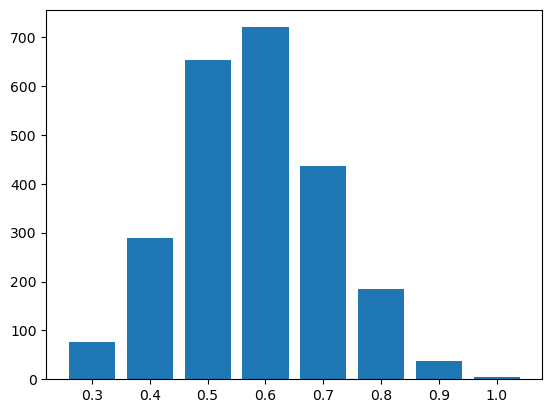

In [7]:
bins = {}
scales = np.array(y_train.squeeze(1))

for scale in scales:
    bins[round(scale, 1)] = bins.get(round(scale, 1), 0) + 1
print(bins)

keys = sorted(bins.keys())
values = [bins[k] for k in keys]
plt.bar([str(key) for key in keys], values)

In [8]:
class MLP(nn.Module):
    def __init__(self, hidden_dim=512):
        super().__init__()
        self.fc1 = nn.Linear(27, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, 1)
        self.relu = nn.ReLU()


    def forward(self, X):
        y = self.fc1(X)
        y = self.relu(y)
        y = self.fc2(y)
        y = self.relu(y)
        y = self.fc3(y)
        return y

model = MLP().to("cuda") 
model.train()

MLP(
  (fc1): Linear(in_features=27, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=512, bias=True)
  (fc3): Linear(in_features=512, out_features=1, bias=True)
  (relu): ReLU()
)

In [9]:
learning_rate = 1e-5
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

Loss = nn.MSELoss()

learning_rate_step_size = 20
learning_rate_gamma = 0.1
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=learning_rate_step_size, gamma=learning_rate_gamma)

In [10]:
min_loss = float('inf')
epoch_loss = []
test_loss = []
slope = []
num_epochs = 150
for epoch in tqdm(range(num_epochs)):
    cumlative_loss = 0
    for X, y in train_dataloader:
        X, y = X.to("cuda"), y.to("cuda")
        y_pred = model(X)
        
        loss = Loss(y_pred, y.float())
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()        
        cumlative_loss += loss.item()

    lr_scheduler.step()
    epoch_loss.append(cumlative_loss/len(train_dataloader))

    X_list = []
    y_list = []
    y_pred_list = []
    with torch.no_grad():
        for X, y in test_dataloader:
            X, y = X.to("cuda"), y.to("cuda")
            y_pred = model(X)
            X_list.append(X)
            y_list.append(y)
            y_pred_list.append(y_pred)

    X_list = torch.cat(X_list, dim=0)
    y_list = torch.cat(y_list, dim=0)
    y_pred_list = torch.cat(y_pred_list, dim=0)
    test_loss.append(Loss(y_pred_list, y_list.float()).item())
    if Loss(y_pred_list, y_list.float()).item() < min_loss:
        min_loss = Loss(y_pred_list, y_list.float()).item()
        torch.save({"model_state": model.state_dict()}, "/u/ericji150/ControlNetAdapter/global_mlp/FeatureMLP.pt")
        print("Lower Loss @ epoch:", epoch)
    y_pred_list = y_pred_list.cpu().squeeze()
    y_list = torch.stack([y_list.cpu().squeeze(), torch.ones_like(y_list.cpu()).squeeze()], dim=1)
    # X_list = (X_list.cpu()*X_std+X_mean)[:,:13]
    # y_pred_list = y_pred_list.cpu().squeeze()/X_list[:,6]
    # y_list = torch.stack([y_list.cpu().squeeze()/X_list[:,6], torch.ones_like(y_list.cpu()).squeeze()], dim=1)
    
    coeffs, *_ = torch.linalg.lstsq(y_list, y_pred_list)
    a = coeffs[0]
    slope.append(a)

# torch.save({"model_state": model.state_dict()}, "/u/ericji150/ControlNetAdapter/global_mlp/FeatureMLP.pt")    
print("Training complete!")

  0%|          | 0/150 [00:00<?, ?it/s]/sw/rh9.4/user/python/conda-env/pytorch-2.8-cu128/lib/python3.11/site-packages/torch/nn/modules/loss.py:616: UserWarning: Using a target size (torch.Size([600])) that is different to the input size (torch.Size([600, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
  1%|          | 1/150 [00:00<02:11,  1.13it/s]

Lower Loss @ epoch: 0


  2%|▏         | 3/150 [00:01<00:49,  2.95it/s]

Lower Loss @ epoch: 1
Lower Loss @ epoch: 2


  3%|▎         | 5/150 [00:01<00:35,  4.14it/s]

...

Lower Loss @ epoch: 89


 65%|██████▍   | 97/150 [00:17<00:09,  5.68it/s]

Lower Loss @ epoch: 95


100%|██████████| 150/150 [00:27<00:00,  5.52it/s]

Training complete!


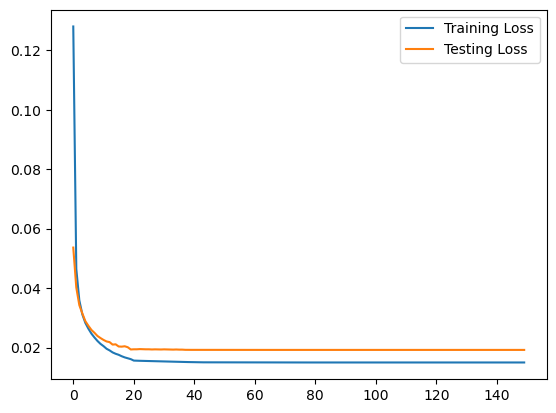

In [11]:
plt.plot(np.arange(num_epochs), epoch_loss, label = "Training Loss")
plt.plot(np.arange(num_epochs), test_loss, label = "Testing Loss")
plt.legend()
plt.show()

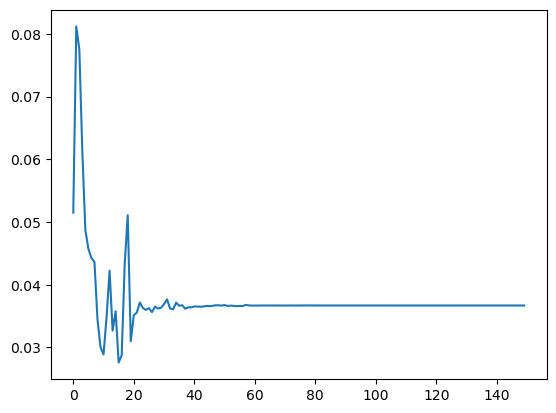

In [12]:
plt.plot(np.arange(num_epochs), slope, label = "Slope")

Baseline MAE: tensor(0.1034, device='cuda:0')
Test MAE: tensor(0.1111, device='cuda:0')
Min MAE: tensor(8.5831e-06, device='cuda:0')
Max MAE: tensor(0.5872, device='cuda:0')
Number of cases predicted below 48


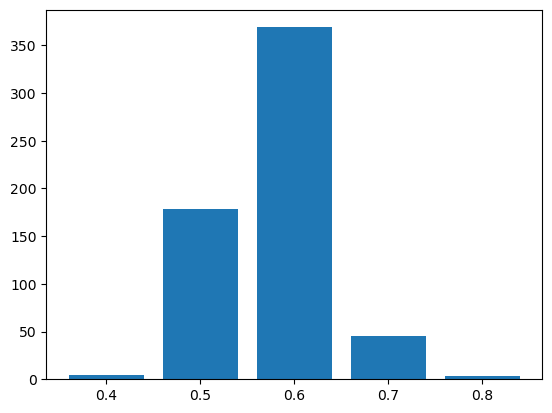

In [13]:
model.eval()
model.load_state_dict(torch.load("FeatureMLP.pt", weights_only=True)["model_state"])

X_list = []
y_list = []
y_pred_list = []
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to("cuda"), y.to("cuda")
        y_pred = model(X)
        X_list.append(X)
        y_list.append(y)
        y_pred_list.append(y_pred)

# X_list = (torch.cat(X_list, dim=0).cpu()*X_std+X_mean).to("cuda")
# y_list = torch.cat(y_list, dim=0)/X_list[:,24].unsqueeze(1)
# y_pred_list = torch.cat(y_pred_list, dim=0)/X_list[:,24].unsqueeze(1)
y_list = torch.cat(y_list, dim=0)
y_pred_list = torch.cat(y_pred_list, dim=0)



loss = torch.abs(y_list-y_pred_list)
print("Baseline MAE:", torch.abs(y_list-y_train.mean()).mean())
print("Test MAE:", torch.mean(loss))
print("Min MAE:", torch.min(loss))
print("Max MAE:", torch.max(loss))

bins = {}
for scale in y_pred_list:
    bins[round(scale.item(), 1)] = bins.get(round(scale.item(), 1), 0) + 1

keys = sorted(bins.keys())
values = [bins[k] for k in keys]
plt.bar([str(key) for key in keys], values)

count = 0
for idx in range(len(y_pred_list)):
    if round(y_list[idx].item(), 2) - round(y_pred_list[idx].item(), 2) > 0.2:
        count += 1
    # if round(y_list[idx].item(), 2) > round(y_pred_list[idx].item(), 2):
    #     print("GT:", round(y_list[idx].item(), 2), "Pred:", round(y_pred_list[idx].item(), 2))
print("Number of cases predicted below", count)

Slope: 0.03668664023280144
Intercept: 0.5535278916358948


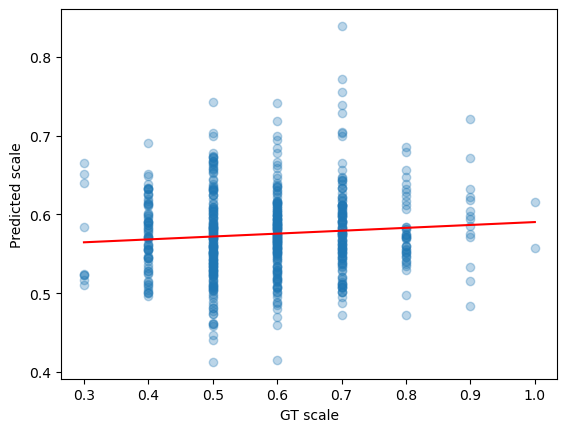

In [14]:
x = y_list.cpu().squeeze()
y = y_pred_list.cpu().squeeze()

X = torch.stack([x, torch.ones_like(x)], dim=1)
coeffs, *_ = torch.linalg.lstsq(X, y)
a = coeffs[0]
b = coeffs[1]

print("Slope:", a.item())
print("Intercept:", b.item())

plt.scatter(x, y, alpha=0.3)
x_line = torch.linspace(x.min(), x.max(), 100)
y_line = a * x_line + b
plt.plot(x_line, y_line, color="red")
plt.xlabel("GT scale")
plt.ylabel("Predicted scale")
plt.show()

